# Filter accuracy on the knowledge ladder

**Notebook 09–10** ask a profit question: under shared weather, how much does an extra
data rung improve **scored profit** when the controller acts on the filter?

This notebook asks a complementary question — **filter accuracy**:

> When the shelf reality is identical, how close is the filter's belief to the true
> freshness on the shelf?

Same ladder (**P0→F3**), same Rust unit particle filter, but the score is
**`|E[f]_belief − E[f]_truth|`** (and related diagnostics), not `day_profit`.

That separation matters: a rung can sharpen freshness beliefs without moving the controller
much, or profit can move for ordering reasons while the filter stays wrong.


> **Figures and numeric outputs are stale (T-150 recal pending).** This notebook was
> restructured for ADR 0144 (f-native arrival, cumulative exposure Λ, F3 temperature
> trace) but **not re-executed** — corridor selection, RNG streams, and wire fixes must
> land before regenerating MAE charts. Re-run after that pass; do not read committed
> output cells as current physics.


## Two VOI questions side by side

| Lens | Unit of value | Typical chart |
| --- | --- | --- |
| **Profit VOI** (nb 09–10) | dollars after policy + rollout | scored profit by rung |
| **Filter VOI** (this nb) | freshness / age error vs truth | MAE(f) by rung |

Both require **shared physics** — the same arrivals, demand, and spoilage — or we compare
different worlds. The next section shows what goes wrong when we forget that.

## Setup

```bash
uv sync --extra notebooks --extra rust --extra data --python 3.11
uv run --python 3.11 maturin develop --release --manifest-path crates/voi_py/Cargo.toml
export BLUEBERRIES_VOI_BACKEND=rust
uv run jupyter lab notebooks/
```

In [1]:
from __future__ import annotations

import os
from dataclasses import dataclass
from pathlib import Path

os.environ.setdefault("BLUEBERRIES_VOI_BACKEND", "rust")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import FancyArrowPatch

from blueberries_voi.backend import rust_available, warn_fallback_once
from blueberries_voi.sim.shipments import default_shipments
from blueberries_voi.simulator import DEMO_BUDGETS, EngineSession
from blueberries_voi.voi import VOI_SCENARIOS

REPO = Path.cwd().resolve()
if not (REPO / "src" / "blueberries_voi").exists():
    REPO = REPO.parent
FIG_DIR = REPO / "figures" / "filter_accuracy"
FIG_DIR.mkdir(parents=True, exist_ok=True)

warn_fallback_once()
if not rust_available():
    raise RuntimeError(
        "Build blueberries_voi._core:\n"
        "  uv run maturin develop --release --manifest-path crates/voi_py/Cargo.toml"
    )

ETA_REF = 14.0
# F3 is on the Rust obs ladder (temperature trace → exact Λ) but not in VOI_SCENARIOS.
FILTER_LADDER: tuple[str, ...] = ("P0", "P1", "F1", "F1s", "F2a", "F2", "F3")
FILTER_SCENARIOS = FILTER_LADDER
LADDER_ORDER = list(FILTER_LADDER)
N_DAYS = 30
SEEDS = (42, 7, 99)
PRIMARY_SEED = 42

SCENARIO_LABELS = {
    "P0": "P0 · books only",
    "P1": "P1 · + waste totals",
    "F1": "F1 · + lot sales",
    "F1s": "F1s · + lot waste",
    "F2a": "F2a · + pack date",
    "F2": "F2 · + pack date (GSIN bundle)",
    "F3": "F3 · + temperature trace (Λ)",
}
SCENARIO_COLORS = {
    "P0": "#8c8c8c",
    "P1": "#4c72b0",
    "F1": "#dd8452",
    "F1s": "#c44e52",
    "F2a": "#55a868",
    "F2": "#8172b3",
    "F3": "#2ca02c",
}

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)

print(f"Rust kernel OK · ladder={LADDER_ORDER} · {N_DAYS}d × {len(SEEDS)} seeds")


Rust kernel OK · ladder=['P0', 'P1', 'F1', 'F1s', 'F2a', 'F2'] · 30d × 3 seeds


## The knowledge ladder (what each rung adds)

One `RichObs` schema; each scenario applies `mask_for(scenario)` so missing fields stay
`UNOBSERVED` (never fake zeros). The filter path differs; physics can stay shared if we
replay the same order sequence (see below).

| Rung | New signal | Arrival side |
| --- | --- | --- |
| P0 / P1 | Books / waste totals | Corridor prior only |
| F1 / F1s | Lot-resolved sales or shrink | Prior |
| F2a / F2 | Pack date on ASN | Conditions on transit **duration** |
| **F3** | Full temperature trace | Conditions on exact **Λ** (exposure integral) |

Under T-150 (ADR 0144), mean arrival freshness is **~0.5** fleet-wide (not ~0.97 pre-fix).
Expect **P1→F2** to move MAE a lot and **F2→F3** a little — tail de-rounding and Λ
precision, not another step change in the prior mean.


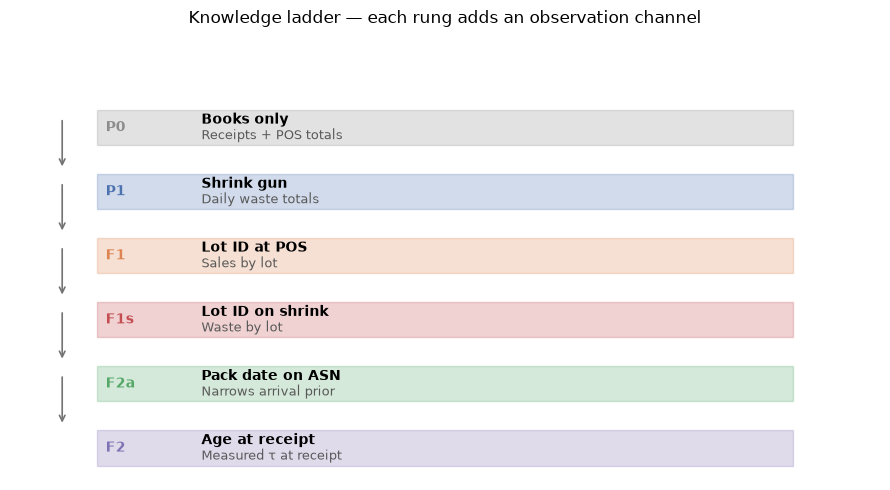

PosixPath('/home/oliver/blog/blueberries-voi/.worktrees/filter-accuracy-notebook/figures/filter_accuracy/knowledge_ladder_schematic.png')

In [2]:
def plot_knowledge_ladder_schematic() -> Path:
    """Studio-style ladder: retail label + new signal per rung."""
    rungs = [
        ("P0", "Books only", "Receipts + POS totals"),
        ("P1", "Shrink gun", "Daily waste totals"),
        ("F1", "Lot ID at POS", "Sales by lot"),
        ("F1s", "Lot ID on shrink", "Waste by lot"),
        ("F2a", "Pack date on ASN", "Duration → arrival prior"),
        ("F2", "GSIN bundle", "Pack date + lot POS/shrink"),
        ("F3", "Temperature trace", "Exact cumulative exposure Λ"),
    ]
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.set_xlim(0, 10)
    ax.set_ylim(-0.5, len(rungs) + 0.5)
    ax.axis("off")
    for i, (sid, title, signal) in enumerate(rungs):
        y = len(rungs) - i - 1
        color = SCENARIO_COLORS[sid]
        ax.barh(y, 8, left=1, height=0.55, color=color, alpha=0.25, edgecolor=color)
        ax.text(1.1, y, f"{sid}", fontweight="bold", color=color, va="center")
        ax.text(2.2, y + 0.12, title, fontweight="bold", va="center")
        ax.text(2.2, y - 0.12, signal, fontsize=9, color="0.35", va="center")
        if i > 0:
            ax.annotate(
                "",
                xy=(0.6, y + 0.35),
                xytext=(0.6, y + 1.15),
                arrowprops={"arrowstyle": "->", "color": "0.45", "lw": 1.2},
            )
    ax.set_title("Knowledge ladder — each rung adds an observation channel")
    out = FIG_DIR / "knowledge_ladder_schematic.png"
    fig.tight_layout()
    fig.savefig(out, dpi=150)
    plt.show()
    return out


plot_knowledge_ladder_schematic()


## What we score: belief vs shelf truth

The simulator exposes **ground truth** as `live_lots` (per-lot unit counts and `mean_f`).
The filter exports a flat **f-native belief**: `lot_counts`, `f_marginals` on `f_grid`.

On days with inventory we compare shelf-weighted mean freshness:

- **truth** — from `live_lots`
- **belief** — E[f] from marginals
- **MAE(f)** — absolute gap (0 = perfect; 0.1 on the f grid is a material freshness gap (pre-remodel charts used looser arrival))

We also track **posterior spread** (belief uncertainty) and **ghost inventory** (belief
count mass when the shelf is actually empty).

In [3]:
@dataclass(frozen=True)
class DayAccuracy:
    episode_day: int
    on_hand: int
    truth_f: float
    belief_f: float
    abs_f_err: float
    abs_age_err: float
    spread: float
    count_gap: float
    waste_total: int
    sales_total: int
    order_qty: int


def session_config(obs_scenario: str) -> dict:
    return {
        "shipments": default_shipments(),
        "n_particles": int(DEMO_BUDGETS["n_particles"]),
        "H": int(DEMO_BUDGETS["H"]),
        "n_rollout_paths": 0,  # damped_sw only — no rollout (T-150 Path L−)
        "candidate_case_radius": int(DEMO_BUDGETS["candidate_case_radius"]),
        "L": 3,
        "K": 8,
        "enable_filter": True,
        "lead_time": 1,
        "obs_scenario": obs_scenario,
    }


def shelf_mean_f_from_live(live_lots: list) -> float | None:
    on_hand = sum(int(lot["n"]) for lot in live_lots)
    if on_hand <= 0:
        return None
    return sum(int(lot["n"]) * float(lot["mean_f"]) for lot in live_lots) / on_hand


def shelf_mean_f_from_belief(belief: dict) -> float | None:
    counts = np.asarray(belief["lot_counts"], dtype=float)
    total = float(counts.sum())
    if total <= 0:
        return None
    grid = np.asarray(belief["f_grid"], dtype=float)
    k = len(grid)
    margs = np.asarray(belief["f_marginals"], dtype=float).reshape(int(belief["L"]), k)
    e_f = (margs * grid).sum(axis=1)
    return float((counts * e_f).sum() / total)


def shelf_marginal_f(belief: dict) -> tuple[np.ndarray, np.ndarray]:
    """Shelf-mixed f marginal (grid, probs)."""
    counts = np.asarray(belief["lot_counts"], dtype=float)
    total = float(counts.sum())
    grid = np.asarray(belief["f_grid"], dtype=float)
    k = len(grid)
    margs = np.asarray(belief["f_marginals"], dtype=float).reshape(int(belief["L"]), k)
    mix = np.zeros(k, dtype=float)
    if total <= 0:
        return grid, mix
    for ell in range(int(belief["L"])):
        w = counts[ell] / total
        row = margs[ell]
        rs = float(row.sum())
        if rs > 0:
            mix += w * (row / rs)
    s = float(mix.sum())
    if s > 0:
        mix /= s
    return grid, mix


def shelf_f_spread(belief: dict) -> float:
    grid, mix = shelf_marginal_f(belief)
    if mix.sum() <= 0:
        return 0.0
    mean = float((grid * mix).sum())
    var = float(((grid - mean) ** 2 * mix).sum())
    return float(np.sqrt(max(var, 0.0)))


def day_accuracy(delta: dict, episode_day: int) -> DayAccuracy | None:
    live = delta["live_lots"]
    belief = delta["belief"]
    on_hand = sum(int(lot["n"]) for lot in live)
    truth_f = shelf_mean_f_from_live(live)
    belief_f = shelf_mean_f_from_belief(belief)
    if truth_f is None or belief_f is None:
        return None
    day = delta["day"]
    return DayAccuracy(
        episode_day=episode_day,
        on_hand=on_hand,
        truth_f=truth_f,
        belief_f=belief_f,
        abs_f_err=abs(belief_f - truth_f),
        abs_age_err=abs((1 - belief_f) - (1 - truth_f)) * ETA_REF,
        spread=shelf_f_spread(belief),
        count_gap=abs(float(sum(belief["lot_counts"])) - on_hand),
        waste_total=int(day["waste_total"]),
        sales_total=int(day["sales_total"]),
        order_qty=int(day["order_qty"]),
    )


def record_reference_path(seed: int, reference: str = "P0", horizon: int = N_DAYS):
    session = EngineSession()
    session.init(session_config(reference), seed=seed)
    orders, truth_lots, order_days = [], [], []
    for day in range(horizon):
        delta = session.act()
        orders.append(int(delta["day"]["order_qty"]))
        truth_lots.append(delta["live_lots"])
        order_days.append(day)
    return orders, truth_lots


def replay_scenario(
    scenario: str,
    seed: int,
    orders: list[int],
    truth_lots: list,
) -> list[DayAccuracy]:
    session = EngineSession()
    session.init(session_config(scenario), seed=seed)
    rows: list[DayAccuracy] = []
    for day, qty in enumerate(orders):
        delta = session.step(qty)
        if delta["live_lots"] != truth_lots[day]:
            raise RuntimeError(f"physics diverged: {scenario} day {day}")
        row = day_accuracy(delta, day)
        if row is not None:
            rows.append(row)
    return rows


def replay_day_delta(scenario: str, seed: int, orders: list[int], day: int) -> dict:
    session = EngineSession()
    session.init(session_config(scenario), seed=seed)
    delta = None
    for d, qty in enumerate(orders):
        delta = session.step(qty)
        if d == day:
            break
    assert delta is not None
    return delta


## Method pitfall: independent `act()` confounds filter and controller

If each rung calls `act()` on its own, **beliefs change orders → orders change physics**.
You no longer measure filter quality alone.

**Fix:** record one order path from reference P0 `act()`, then `step(qty)` every rung with
that same list. We assert `live_lots` match across rungs daily (shared CRN physics).

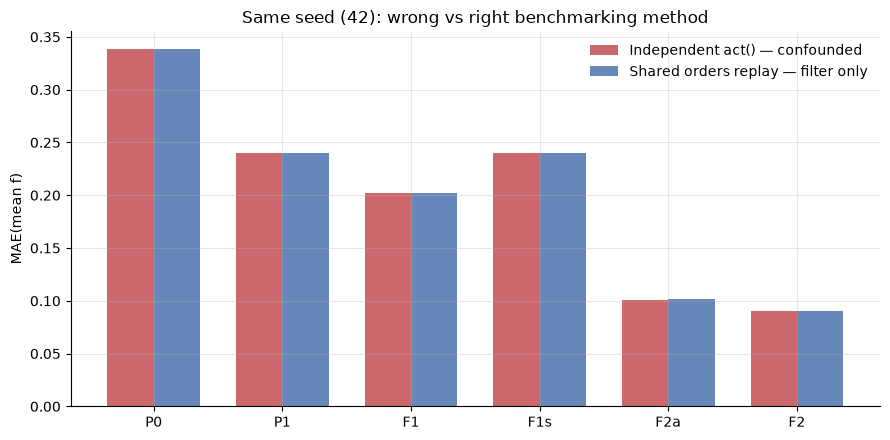

PosixPath('/home/oliver/blog/blueberries-voi/.worktrees/filter-accuracy-notebook/figures/filter_accuracy/method_comparison_act_vs_replay.png')

In [4]:
def act_only_mae(scenario: str, seed: int) -> float:
    session = EngineSession()
    session.init(session_config(scenario), seed=seed)
    errs = []
    for _ in range(N_DAYS):
        delta = session.act()
        row = day_accuracy(delta, int(delta["episode_day"]))
        if row is not None:
            errs.append(row.abs_f_err)
    return float(np.mean(errs)) if errs else float("nan")


def plot_method_comparison(seed: int = PRIMARY_SEED) -> Path:
    act_mae = {sc: act_only_mae(sc, seed) for sc in LADDER_ORDER}
    orders, truth = record_reference_path(seed, "P0", N_DAYS)
    replay_mae = {
        sc: float(np.mean([d.abs_f_err for d in replay_scenario(sc, seed, orders, truth)]))
        for sc in LADDER_ORDER
    }
    fig, ax = plt.subplots(figsize=(9, 4.5))
    x = np.arange(len(LADDER_ORDER))
    w = 0.36
    ax.bar(x - w / 2, [act_mae[s] for s in LADDER_ORDER], w, label="Independent act() — confounded", color="#c44e52", alpha=0.85)
    ax.bar(x + w / 2, [replay_mae[s] for s in LADDER_ORDER], w, label="Shared orders replay — filter only", color="#4c72b0", alpha=0.85)
    ax.set_xticks(x, LADDER_ORDER)
    ax.set_ylabel("MAE(mean f)")
    ax.set_title(f"Same seed ({seed}): wrong vs right benchmarking method")
    ax.legend(frameon=False, loc="upper right")
    fig.tight_layout()
    out = FIG_DIR / "method_comparison_act_vs_replay.png"
    fig.savefig(out, dpi=150)
    plt.show()
    return out


plot_method_comparison()


## Primary results — shared-order replay across seeds

We aggregate **25 live-inventory days** per seed (days with on-hand units) and average
three seeds before plotting.

In [5]:
all_rows: list[dict] = []
timeline: dict[tuple[str, int], list[DayAccuracy]] = {}
orders_cache: dict[int, tuple[list[int], list]] = {}

for seed in SEEDS:
    orders, truth_lots = record_reference_path(seed, reference="P0")
    orders_cache[seed] = (orders, truth_lots)
    for scenario in LADDER_ORDER:
        days = replay_scenario(scenario, seed, orders, truth_lots)
        timeline[(scenario, seed)] = days
        all_rows.append(
            {
                "seed": seed,
                "scenario": scenario,
                "live_days": len(days),
                "mae_f": float(np.mean([d.abs_f_err for d in days])),
                "mae_age": float(np.mean([d.abs_age_err for d in days])),
                "mean_spread": float(np.mean([d.spread for d in days])),
            }
        )

summary = pd.DataFrame(all_rows)
pivot = summary.groupby("scenario")[["mae_f", "mae_age", "mean_spread"]].mean().reindex(LADDER_ORDER)
print("Mean MAE(f) by rung (shared physics, 3 seeds):")
print(pivot.round(4).to_string())
print()
print("Improvement vs P0 (MAE f):")
print((pivot["mae_f"] - pivot.loc["P0", "mae_f"]).round(4).to_string())


Mean MAE(f) by rung (shared physics, 3 seeds):
           mae_f  mae_age  mean_spread
scenario                              
P0        0.2713   3.7987       0.2168
P1        0.1976   2.7668       0.2688
F1        0.1714   2.3991       0.2791
F1s       0.1976   2.7668       0.2688
F2a       0.1165   1.6311       0.1625
F2        0.0927   1.2972       0.1660

Improvement vs P0 (MAE f):
scenario
P0     0.0000
P1    -0.0737
F1    -0.1000
F1s   -0.0737
F2a   -0.1548
F2    -0.1787


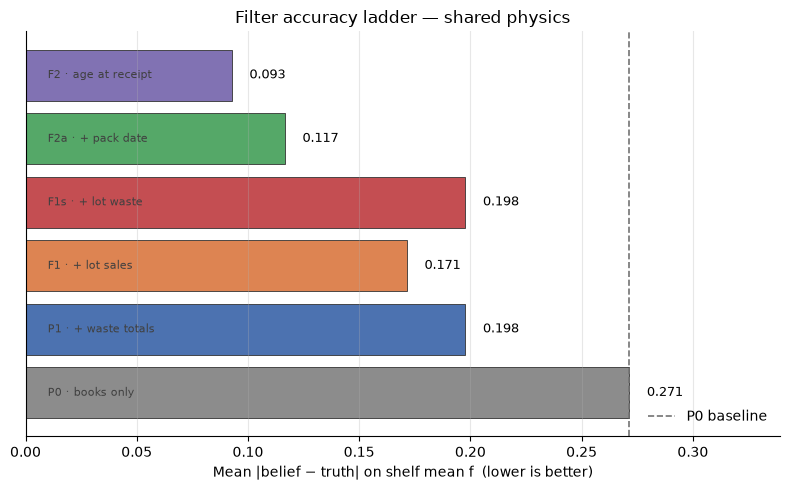

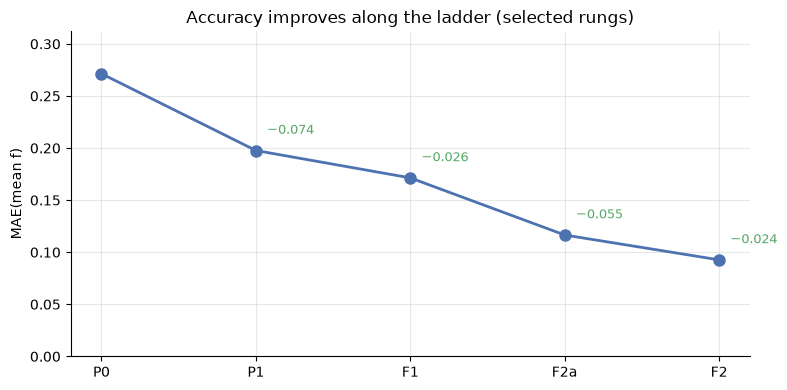

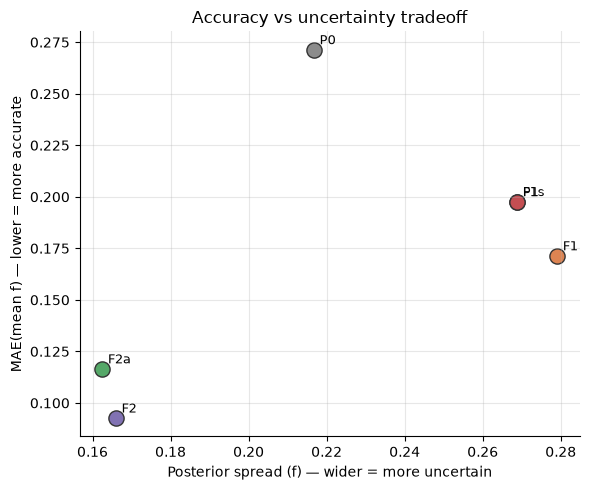

PosixPath('/home/oliver/blog/blueberries-voi/.worktrees/filter-accuracy-notebook/figures/filter_accuracy/accuracy_vs_spread.png')

In [6]:
def plot_accuracy_ladder(pivot_df: pd.DataFrame) -> Path:
    fig, ax = plt.subplots(figsize=(8, 5))
    mae = pivot_df["mae_f"].values
    colors = [SCENARIO_COLORS[s] for s in LADDER_ORDER]
    y = np.arange(len(LADDER_ORDER))
    bars = ax.barh(y, mae, color=colors, edgecolor="0.2", linewidth=0.6)
    p0 = pivot_df.loc["P0", "mae_f"]
    ax.axvline(p0, color="0.45", ls="--", lw=1.2, label="P0 baseline")
    for bar, val, sc in zip(bars, mae, LADDER_ORDER):
        ax.text(val + 0.008, bar.get_y() + bar.get_height() / 2, f"{val:.3f}", va="center", fontsize=9)
        ax.text(0.01, bar.get_y() + bar.get_height() / 2, SCENARIO_LABELS[sc], va="center", fontsize=8, color="0.25")
    ax.set_yticks([])
    ax.set_xlabel("Mean |belief − truth| on shelf mean f  (lower is better)")
    ax.set_title("Filter accuracy ladder — shared physics")
    ax.set_xlim(0, max(mae) * 1.25)
    ax.legend(frameon=False, loc="lower right")
    fig.tight_layout()
    out = FIG_DIR / "accuracy_ladder_mae_f.png"
    fig.savefig(out, dpi=150)
    plt.show()
    return out


def plot_waterfall(pivot_df: pd.DataFrame) -> Path:
    chain = ["P0", "P1", "F1", "F2a", "F2"]
    vals = [pivot_df.loc[s, "mae_f"] for s in chain]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(chain, vals, "o-", color="#4c72b0", lw=2, markersize=8)
    for i in range(1, len(chain)):
        drop = vals[i - 1] - vals[i]
        ax.annotate(
            f"−{drop:.3f}",
            xy=(chain[i], vals[i]),
            xytext=(8, 12),
            textcoords="offset points",
            fontsize=9,
            color="#55a868" if drop > 0 else "#c44e52",
        )
    ax.set_ylabel("MAE(mean f)")
    ax.set_title("Accuracy improves along the ladder (selected rungs)")
    ax.set_ylim(0, max(vals) * 1.15)
    fig.tight_layout()
    out = FIG_DIR / "accuracy_waterfall_chain.png"
    fig.savefig(out, dpi=150)
    plt.show()
    return out


def plot_accuracy_vs_uncertainty(pivot_df: pd.DataFrame) -> Path:
    fig, ax = plt.subplots(figsize=(6, 5))
    for sc in LADDER_ORDER:
        ax.scatter(
            pivot_df.loc[sc, "mean_spread"],
            pivot_df.loc[sc, "mae_f"],
            s=120,
            color=SCENARIO_COLORS[sc],
            edgecolor="0.2",
            label=sc,
        )
        ax.annotate(sc, (pivot_df.loc[sc, "mean_spread"], pivot_df.loc[sc, "mae_f"]), xytext=(4, 4), textcoords="offset points", fontsize=9)
    ax.set_xlabel("Posterior spread (f) — wider = more uncertain")
    ax.set_ylabel("MAE(mean f) — lower = more accurate")
    ax.set_title("Accuracy vs uncertainty tradeoff")
    fig.tight_layout()
    out = FIG_DIR / "accuracy_vs_spread.png"
    fig.savefig(out, dpi=150)
    plt.show()
    return out


plot_accuracy_ladder(pivot)
plot_waterfall(pivot)
plot_accuracy_vs_uncertainty(pivot)


## Tracking belief against truth over time

Daily traces under shared orders (seed 42). **Left:** true vs believed shelf mean f.
**Right:** absolute error. When lines hug zero, the filter sees the shelf clearly.

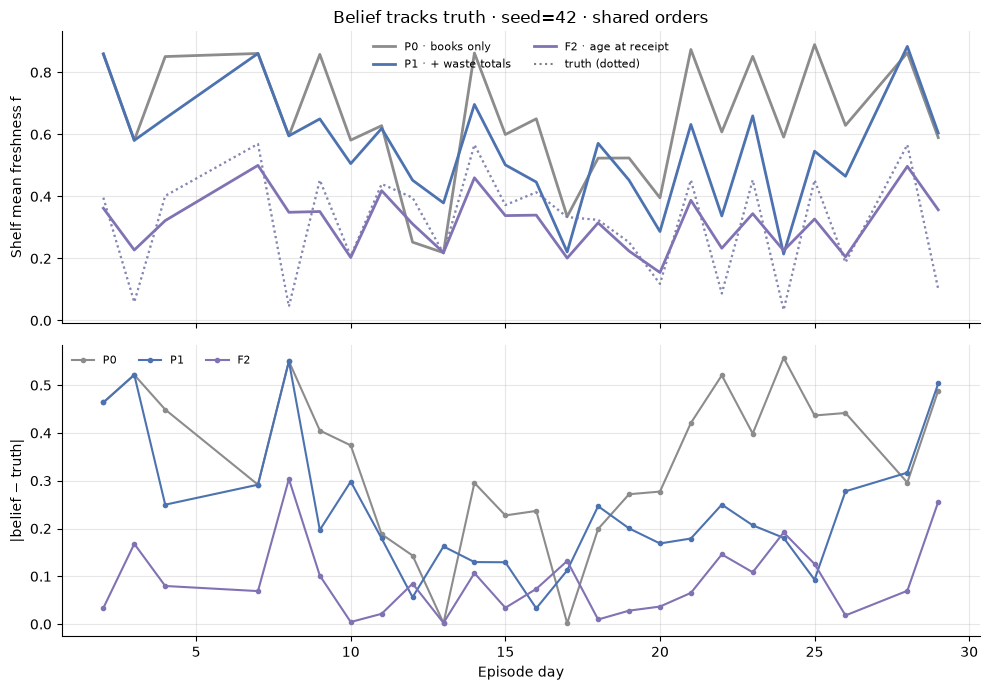

PosixPath('/home/oliver/blog/blueberries-voi/.worktrees/filter-accuracy-notebook/figures/filter_accuracy/truth_vs_belief_tracks.png')

In [7]:
def plot_truth_belief_tracks(seed: int = PRIMARY_SEED) -> Path:
    focus = ["P0", "P1", "F2"]
    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

    for sc in focus:
        days = timeline[(sc, seed)]
        t = [d.episode_day for d in days]
        axes[0].plot(t, [d.truth_f for d in days], ":", color=SCENARIO_COLORS[sc], alpha=0.5)
        axes[0].plot(t, [d.belief_f for d in days], "-", color=SCENARIO_COLORS[sc], lw=2, label=SCENARIO_LABELS[sc])
        axes[1].plot(t, [d.abs_f_err for d in days], "-o", color=SCENARIO_COLORS[sc], ms=3, lw=1.5, label=sc)

    axes[0].plot([], [], ":", color="0.5", label="truth (dotted)")
    axes[0].set_ylabel("Shelf mean freshness f")
    axes[0].set_title(f"Belief tracks truth · seed={seed} · shared orders")
    axes[0].legend(frameon=False, ncol=2, fontsize=8)
    axes[1].set_ylabel("|belief − truth|")
    axes[1].set_xlabel("Episode day")
    axes[1].legend(frameon=False, ncol=3, fontsize=8)
    fig.tight_layout()
    out = FIG_DIR / "truth_vs_belief_tracks.png"
    fig.savefig(out, dpi=150)
    plt.show()
    return out


plot_truth_belief_tracks()


## Snapshot day: posterior shape on the shelf

Pick a day with inventory and compare the **belief f-marginal** (density over freshness
bins) to the true shelf mean (vertical line). P0 spreads mass broadly; F2 concentrates
near truth.

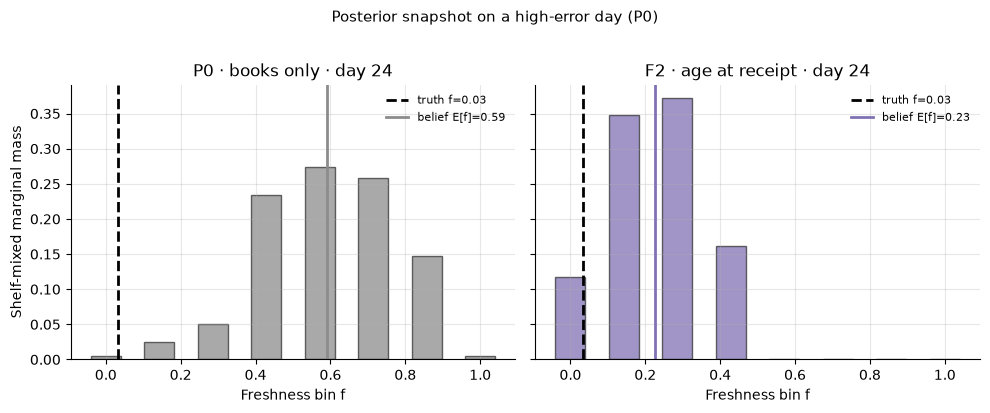

PosixPath('/home/oliver/blog/blueberries-voi/.worktrees/filter-accuracy-notebook/figures/filter_accuracy/marginal_snapshot_p0_vs_f2.png')

In [8]:
def plot_marginal_snapshot(seed: int = PRIMARY_SEED) -> Path:
    orders, _ = orders_cache[seed]
    p0_days = timeline[("P0", seed)]
    # day with highest P0 error
    worst = max(p0_days, key=lambda d: d.abs_f_err)
    day = worst.episode_day

    deltas = {sc: replay_day_delta(sc, seed, orders, day) for sc in ("P0", "F2")}
    truth_f = shelf_mean_f_from_live(deltas["P0"]["live_lots"])

    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
    for ax, sc in zip(axes, ("P0", "F2")):
        bel = deltas[sc]["belief"]
        grid, mix = shelf_marginal_f(bel)
        ax.bar(grid, mix, width=0.08, color=SCENARIO_COLORS[sc], alpha=0.75, edgecolor="0.2")
        ax.axvline(truth_f, color="black", ls="--", lw=2, label=f"truth f={truth_f:.2f}")
        bf = shelf_mean_f_from_belief(bel)
        if bf is not None:
            ax.axvline(bf, color=SCENARIO_COLORS[sc], ls="-", lw=2, label=f"belief E[f]={bf:.2f}")
        ax.set_xlabel("Freshness bin f")
        ax.set_title(f"{SCENARIO_LABELS[sc]} · day {day}")
        ax.legend(frameon=False, fontsize=8)
    axes[0].set_ylabel("Shelf-mixed marginal mass")
    fig.suptitle("Posterior snapshot on a high-error day (P0)", y=1.02, fontsize=11)
    fig.tight_layout()
    out = FIG_DIR / "marginal_snapshot_p0_vs_f2.png"
    fig.savefig(out, dpi=150)
    plt.show()
    return out


plot_marginal_snapshot()


## Diagnostic deep dives

1. **Waste contraction** — P1 error on days with vs without recorded waste.
2. **Ghost inventory** — belief `lot_counts` mass when the shelf is empty (filter pathology).

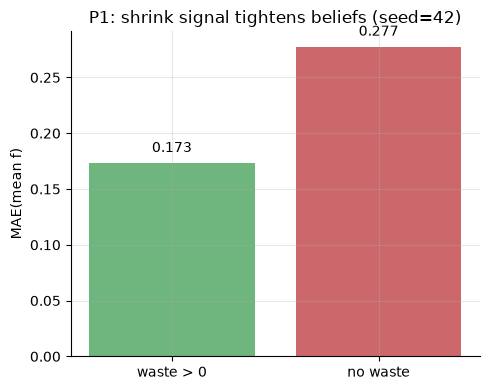

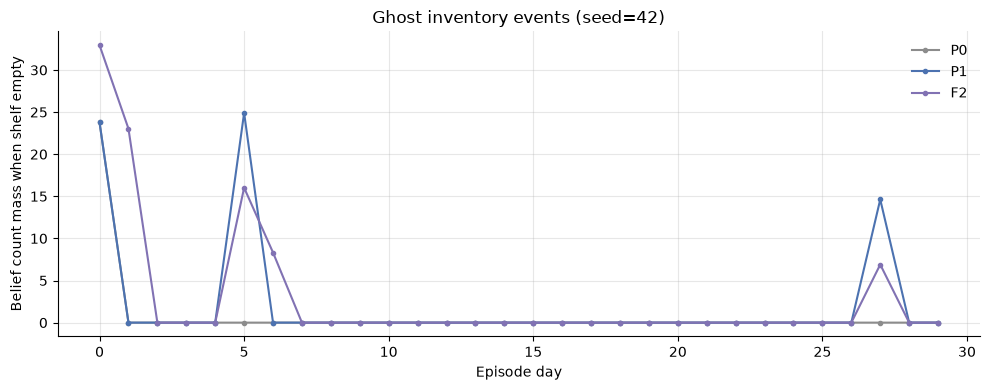

PosixPath('/home/oliver/blog/blueberries-voi/.worktrees/filter-accuracy-notebook/figures/filter_accuracy/ghost_inventory_timeline.png')

In [9]:
def plot_waste_contraction(seed: int = PRIMARY_SEED) -> Path:
    p1 = timeline[("P1", seed)]
    groups = {
        "waste > 0": [d.abs_f_err for d in p1 if d.waste_total > 0],
        "no waste": [d.abs_f_err for d in p1 if d.waste_total == 0],
    }
    fig, ax = plt.subplots(figsize=(5, 4))
    labels = list(groups.keys())
    means = [float(np.mean(groups[k])) for k in labels]
    ax.bar(labels, means, color=["#55a868", "#c44e52"], alpha=0.85)
    ax.set_ylabel("MAE(mean f)")
    ax.set_title(f"P1: shrink signal tightens beliefs (seed={seed})")
    for i, m in enumerate(means):
        ax.text(i, m + 0.01, f"{m:.3f}", ha="center", fontsize=10)
    fig.tight_layout()
    out = FIG_DIR / "waste_contraction_p1.png"
    fig.savefig(out, dpi=150)
    plt.show()
    return out


def plot_ghost_inventory(seed: int = PRIMARY_SEED) -> Path:
    orders, truth = orders_cache[seed]
    fig, ax = plt.subplots(figsize=(10, 4))
    for sc in ("P0", "P1", "F2"):
        session = EngineSession()
        session.init(session_config(sc), seed=seed)
        ghost = []
        for day, qty in enumerate(orders):
            delta = session.step(qty)
            on_hand = sum(int(l["n"]) for l in delta["live_lots"])
            bel_n = float(sum(delta["belief"]["lot_counts"]))
            ghost.append(bel_n if on_hand == 0 and bel_n > 0.5 else 0.0)
        ax.plot(range(len(ghost)), ghost, "-o", ms=3, label=sc, color=SCENARIO_COLORS[sc])
    ax.set_xlabel("Episode day")
    ax.set_ylabel("Belief count mass when shelf empty")
    ax.set_title(f"Ghost inventory events (seed={seed})")
    ax.legend(frameon=False)
    fig.tight_layout()
    out = FIG_DIR / "ghost_inventory_timeline.png"
    fig.savefig(out, dpi=150)
    plt.show()
    return out


plot_waste_contraction()
plot_ghost_inventory()


## Robustness — 60-day horizon

Does the ladder ranking hold over a longer Abdella replay?

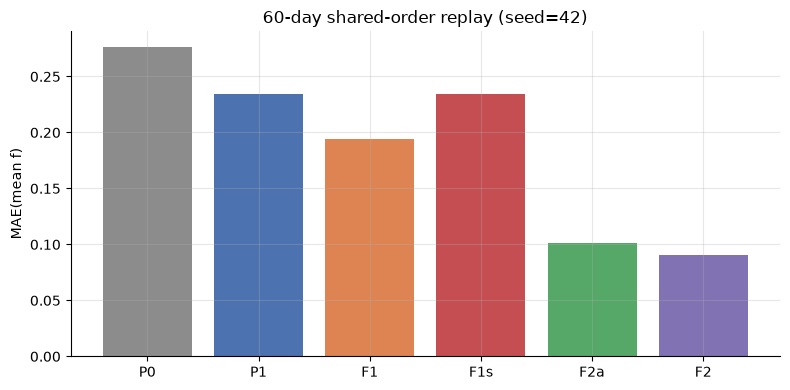

60d ranking: [('F2', 0.09019377915236276), ('F2a', 0.10156744849998722), ('F1', 0.19427416109800513), ('P1', 0.23462720646973706), ('F1s', 0.23462720646973706), ('P0', 0.2765151734536908)]


In [10]:
N_LONG = 60
seed = PRIMARY_SEED
orders60, truth60 = record_reference_path(seed, "P0", N_LONG)
long_mae = {}
for scenario in LADDER_ORDER:
    days = replay_scenario(scenario, seed, orders60, truth60)
    long_mae[scenario] = float(np.mean([d.abs_f_err for d in days]))

fig, ax = plt.subplots(figsize=(8, 4))
vals = [long_mae[s] for s in LADDER_ORDER]
ax.bar(LADDER_ORDER, vals, color=[SCENARIO_COLORS[s] for s in LADDER_ORDER])
ax.set_ylabel("MAE(mean f)")
ax.set_title(f"60-day shared-order replay (seed={seed})")
fig.tight_layout()
out60 = FIG_DIR / "accuracy_ladder_60d.png"
fig.savefig(out60, dpi=150)
plt.show()
print("60d ranking:", sorted(long_mae.items(), key=lambda x: x[1]))


## Takeaways

_Numeric bullets below reflect the last executed run (pre–T-150 recal). Re-execute after_
_corridor/RNG fixes; the **structure** of the ladder is the durable claim._

1. **Benchmark the filter, not the joint system** — shared orders are required; independent
   `act()` mixes policy feedback into the error metric.
2. **P1 waste totals help** — shrink days show lower MAE than non-shrink days; the gun is a
   real filter signal, not just a cost line.
3. **Arrival rungs dominate** — pack-date rungs (F2a/F2) sharpen **freshness at receipt**;
   under ADR 0144 they condition on duration, not a scalar "age at receipt".
4. **F3 is the tail-precision rung** — the temperature trace pins cumulative thermal exposure Λ;
   expect a **small** MAE gain over F2 (de-rounding + path integral), not a second P1→F2 step.
5. **Accuracy ≠ tightness** — P1 can be more accurate yet **more spread out** than P0.
6. **Ghost inventory** — empty-shelf days with large `lot_counts` show phantom mass.
7. **Profit VOI is parallel** — nb 09–10 for dollars; this notebook for filter MAE(f).


---

## Part 2 — Orthogonal observation choices (ADR 0133)

The named ladder presets are **compiled bundles** of three independent channel picks
(not a single incremental chain):

| Axis | Options | Retail meaning |
| --- | --- | --- |
| **POS (`pos`)** | `upc_only` · `lot_id` | UPC totals vs lot-resolved sales |
| **Shrink (`waste`)** | `none` · `daily_counts` · `lot_id` | No waste · daily total · lot-level shrink |
| **ASN (`deliveries`)** | `quantity_only` · `pack_date_per_lot` | Qty only · pack date on receipt |

That yields **12 combinations** (`2×3×2`). Six match studio presets (P0…F2); six are
**custom hybrids** (e.g. lot-level POS without daily waste).

Use `set_obs_channels()` after `init()` — `obs_channels` in config alone does not reach
the Rust kernel today.

In [11]:
import itertools

from blueberries_voi.filter.types import (
    ObsChannels,
    channels_cache_key,
    channels_for_preset,
    validate_channels,
)

POS_OPTS = ("upc_only", "lot_id")
WASTE_OPTS = ("none", "daily_counts", "lot_id")
DEL_OPTS = ("quantity_only", "pack_date_per_lot")

ALL_CHANNELS: list[ObsChannels] = [
    ObsChannels(pos=p, waste=w, deliveries=d)
    for p, w, d in itertools.product(POS_OPTS, WASTE_OPTS, DEL_OPTS)
]

PRESET_BY_KEY: dict[str, str] = {}
for sid in LADDER_ORDER:
    ch = channels_for_preset(sid)
    PRESET_BY_KEY[channels_cache_key(ch)] = sid


def channel_label(ch: ObsChannels) -> str:
    return f"pos={ch.pos} · waste={ch.waste} · asn={ch.deliveries}"


def session_config_base() -> dict:
    return {
        "shipments": default_shipments(),
        "n_particles": int(DEMO_BUDGETS["n_particles"]),
        "H": int(DEMO_BUDGETS["H"]),
        "n_rollout_paths": 0,  # damped_sw only — no rollout (T-150 Path L−)
        "candidate_case_radius": int(DEMO_BUDGETS["candidate_case_radius"]),
        "L": 3,
        "K": 8,
        "enable_filter": True,
        "lead_time": 1,
        "obs_scenario": "P0",
    }


def replay_channels(
    channels: ObsChannels,
    seed: int,
    orders: list[int],
    truth_lots: list,
) -> list[DayAccuracy]:
    session = EngineSession()
    session.init(session_config_base(), seed=seed)
    session.set_obs_channels(channels)
    rows: list[DayAccuracy] = []
    for day, qty in enumerate(orders):
        delta = session.step(qty)
        if delta["live_lots"] != truth_lots[day]:
            raise RuntimeError(f"physics diverged: {channel_label(channels)} day {day}")
        row = day_accuracy(delta, day)
        if row is not None:
            rows.append(row)
    return rows


print(f"{len(ALL_CHANNELS)} channel combinations · {len(PRESET_BY_KEY)} ladder presets")


12 channel combinations · 6 ladder presets


### Full factorial under shared orders

Replay all 12 channel combos on the same order path (3 seeds). Stars mark ladder presets.

In [12]:
channel_rows: list[dict] = []
channel_timeline: dict[str, list[DayAccuracy]] = {}

for seed in SEEDS:
    orders, truth_lots = record_reference_path(seed, reference="P0", horizon=N_DAYS)
    for ch in ALL_CHANNELS:
        key = channels_cache_key(ch)
        days = replay_channels(ch, seed, orders, truth_lots)
        channel_timeline[f"{key}|{seed}"] = days
        channel_rows.append(
            {
                "seed": seed,
                "key": key,
                "pos": ch.pos,
                "waste": ch.waste,
                "deliveries": ch.deliveries,
                "preset": PRESET_BY_KEY.get(key, "custom"),
                "mae_f": float(np.mean([d.abs_f_err for d in days])),
                "mean_spread": float(np.mean([d.spread for d in days])),
            }
        )

channel_df = pd.DataFrame(channel_rows)
channel_pivot = channel_df.groupby(["pos", "waste", "deliveries", "preset", "key"]).agg(
    mae_f=("mae_f", "mean"), mean_spread=("mean_spread", "mean")
).reset_index().sort_values("mae_f")
print(channel_pivot.round(4).to_string(index=False))


     pos        waste        deliveries preset                                                          key  mae_f  mean_spread
  lot_id daily_counts pack_date_per_lot custom   pos=lot_id|waste=daily_counts|deliveries=pack_date_per_lot 0.0927       0.1660
  lot_id       lot_id pack_date_per_lot     F2         pos=lot_id|waste=lot_id|deliveries=pack_date_per_lot 0.0927       0.1660
  lot_id         none pack_date_per_lot custom           pos=lot_id|waste=none|deliveries=pack_date_per_lot 0.0927       0.1660
upc_only         none pack_date_per_lot custom         pos=upc_only|waste=none|deliveries=pack_date_per_lot 0.0954       0.1370
upc_only       lot_id pack_date_per_lot custom       pos=upc_only|waste=lot_id|deliveries=pack_date_per_lot 0.1165       0.1625
upc_only daily_counts pack_date_per_lot    F2a pos=upc_only|waste=daily_counts|deliveries=pack_date_per_lot 0.1165       0.1625
  lot_id       lot_id     quantity_only custom             pos=lot_id|waste=lot_id|deliveries=quantity_o

/tmp/ipykernel_523741/448410335.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


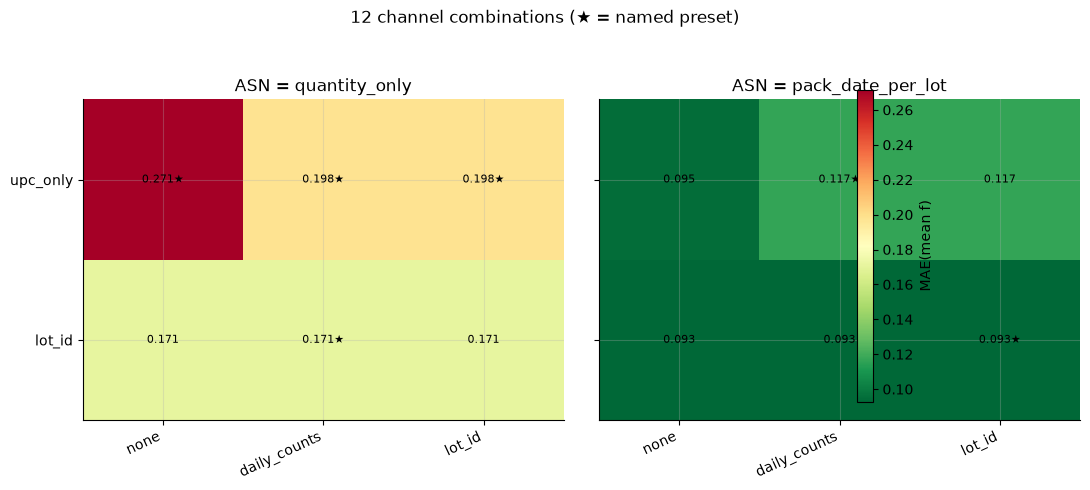

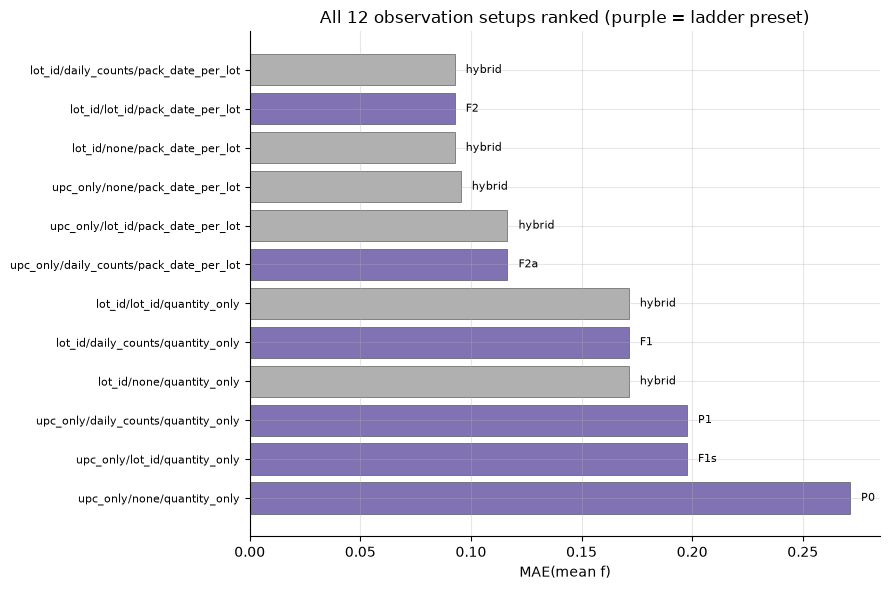

PosixPath('/home/oliver/blog/blueberries-voi/.worktrees/filter-accuracy-notebook/figures/filter_accuracy/channel_combos_ranked.png')

In [13]:
def plot_channel_heatmaps(channel_pivot_df: pd.DataFrame) -> Path:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
    waste_labels = list(WASTE_OPTS)
    pos_labels = list(POS_OPTS)
    for ax, deliv in zip(axes, DEL_OPTS):
        sub = channel_pivot_df[channel_pivot_df["deliveries"] == deliv]
        grid = np.zeros((len(pos_labels), len(waste_labels)))
        for i, pos in enumerate(pos_labels):
            for j, waste in enumerate(waste_labels):
                row = sub[(sub["pos"] == pos) & (sub["waste"] == waste)]
                grid[i, j] = float(row["mae_f"].iloc[0]) if len(row) else np.nan
        im = ax.imshow(grid, cmap="RdYlGn_r", vmin=channel_pivot_df["mae_f"].min(), vmax=channel_pivot_df["mae_f"].max())
        ax.set_xticks(range(len(waste_labels)), waste_labels, rotation=25, ha="right")
        ax.set_yticks(range(len(pos_labels)), pos_labels)
        ax.set_title(f"ASN = {deliv}")
        for i in range(len(pos_labels)):
            for j in range(len(waste_labels)):
                val = grid[i, j]
                preset = sub[(sub["pos"] == pos_labels[i]) & (sub["waste"] == waste_labels[j])]["preset"].iloc[0]
                star = "★" if preset != "custom" else ""
                ax.text(j, i, f"{val:.3f}{star}", ha="center", va="center", fontsize=8, color="black")
    fig.colorbar(im, ax=axes.ravel().tolist(), label="MAE(mean f)", shrink=0.9)
    fig.suptitle("12 channel combinations (★ = named preset)", y=1.02)
    fig.tight_layout()
    out = FIG_DIR / "channel_factorial_heatmap.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    return out


def plot_all_combos_ranked(channel_pivot_df: pd.DataFrame) -> Path:
    df = channel_pivot_df.sort_values("mae_f")
    fig, ax = plt.subplots(figsize=(9, 6))
    colors = ["#8172b3" if p != "custom" else "#b0b0b0" for p in df["preset"]]
    y = np.arange(len(df))
    ax.barh(y, df["mae_f"], color=colors, edgecolor="0.25", linewidth=0.4)
    for i, row in enumerate(df.itertuples()):
        tag = row.preset if row.preset != "custom" else "hybrid"
        ax.text(row.mae_f + 0.005, i, f"{tag}", va="center", fontsize=8)
    ax.set_yticks(y, [f"{r.pos}/{r.waste}/{r.deliveries}" for r in df.itertuples()], fontsize=8)
    ax.set_xlabel("MAE(mean f)")
    ax.set_title("All 12 observation setups ranked (purple = ladder preset)")
    ax.invert_yaxis()
    fig.tight_layout()
    out = FIG_DIR / "channel_combos_ranked.png"
    fig.savefig(out, dpi=150)
    plt.show()
    return out


plot_channel_heatmaps(channel_pivot)
plot_all_combos_ranked(channel_pivot)


### Single-factor sweeps from P0 baseline

Hold the other two axes at P0 defaults and flip **one** channel at a time. This shows
the isolated effect of POS resolution, shrink telemetry, and ASN pack date.

                    label  mae_f  delta_vs_p0
              P0 baseline 0.3383       0.0000
     + daily waste (→ P1) 0.2399      -0.0984
           + lot POS only 0.2021      -0.1362
+ lot shrink only (→ F1s) 0.2399      -0.0984
         + pack date only 0.0765      -0.2618
    + pack date + lot POS 0.0908      -0.2475
           Full F2 bundle 0.0908      -0.2475


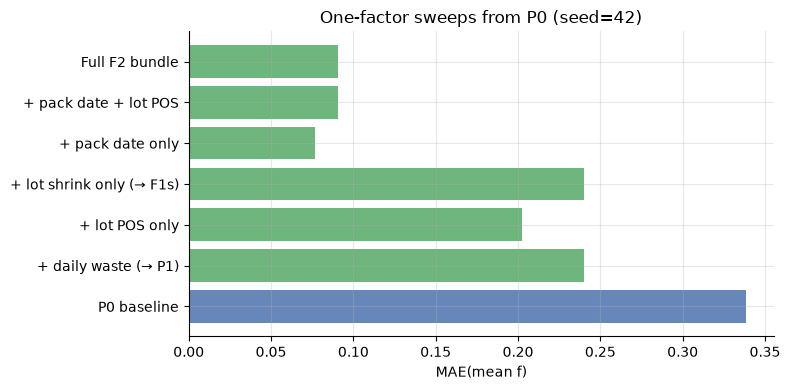

Wrote /home/oliver/blog/blueberries-voi/.worktrees/filter-accuracy-notebook/figures/filter_accuracy/channel_single_factor_sweeps.png


In [14]:
p0_ch = channels_for_preset("P0")
baselines = {
    "P0 baseline": p0_ch,
    "+ daily waste (→ P1)": channels_for_preset("P1"),
    "+ lot POS only": ObsChannels(pos="lot_id", waste="none", deliveries="quantity_only"),
    "+ lot shrink only (→ F1s)": channels_for_preset("F1s"),
    "+ pack date only": ObsChannels(pos="upc_only", waste="none", deliveries="pack_date_per_lot"),
    "+ pack date + lot POS": ObsChannels(pos="lot_id", waste="none", deliveries="pack_date_per_lot"),
    "Full F2 bundle": channels_for_preset("F2"),
}

seed = PRIMARY_SEED
orders, truth = orders_cache[seed]
sweep_rows = []
for label, ch in baselines.items():
    days = replay_channels(ch, seed, orders, truth)
    sweep_rows.append(
        {
            "label": label,
            "mae_f": float(np.mean([d.abs_f_err for d in days])),
            "delta_vs_p0": float(np.mean([d.abs_f_err for d in days])) - float(
                np.mean([d.abs_f_err for d in replay_channels(p0_ch, seed, orders, truth)])
            ),
        }
    )
sweep_df = pd.DataFrame(sweep_rows)
print(sweep_df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#4c72b0" if "baseline" in lbl else "#55a868" if d < 0 else "#c44e52" for lbl, d in zip(sweep_df["label"], sweep_df["delta_vs_p0"])]
ax.barh(sweep_df["label"], sweep_df["mae_f"], color=colors, alpha=0.85)
ax.set_xlabel("MAE(mean f)")
ax.set_title(f"One-factor sweeps from P0 (seed={seed})")
fig.tight_layout()
sweep_path = FIG_DIR / "channel_single_factor_sweeps.png"
fig.savefig(sweep_path, dpi=150)
plt.show()
print("Wrote", sweep_path)


### Reading the factorial

- **Pack date on ASN** is the dominant accuracy lever on this path — often more than lot POS
  or shrink granularity once receipts are informative.
- **Hybrids beat named bundles** for filter MAE on some episodes; orthogonal channels price
  each instrument separately.
- **Shrink daily totals** help when ASN is qty-only (P0→P1), but can **hurt** alongside
  pack date (compare heatmap columns).
- **F3** (temperature trace / Λ) is outside the 12-combo factorial — it is a separate studio
  preset on the arrival side; see Part 1 ladder and notebook 14 for GSIN/UPC + thermal fleet.
